In [19]:
#XGBoost

In [20]:
# XGBoost est un algorithme de machine learning (apprentissage supervisé) basé sur le boosting qui construit plusieurs arbres de décision
#de manière séquentielle, chaque arbre corrige les erreurs du précédent, son objectif est d’obtenir une très haute performance
#en prédiction et classification.

PRÉDICTION INITIALE : [30. 30. 30. 30. 30.]

ARBRE NUMÉRO 1
ERREURS : [-20. -10.   0.  10.  20.]
MEILLEUR SEUIL : 1
VALEUR GAUCHE : -20.0
VALEUR DROITE : 5.0
PRÉDICTION MISE À JOUR : [24.  31.5 31.5 31.5 31.5]

ARBRE NUMÉRO 2
ERREURS : [-14.  -11.5  -1.5   8.5  18.5]
MEILLEUR SEUIL : 4
VALEUR GAUCHE : -4.625
VALEUR DROITE : 18.5
PRÉDICTION MISE À JOUR : [22.6125 30.1125 30.1125 30.1125 37.05  ]

ARBRE NUMÉRO 3
ERREURS : [-12.6125 -10.1125  -0.1125   9.8875  12.95  ]
MEILLEUR SEUIL : 3
VALEUR GAUCHE : -7.612500000000001
VALEUR DROITE : 11.418750000000001
PRÉDICTION MISE À JOUR : [20.32875  27.82875  27.82875  33.538125 40.475625]

ARBRE NUMÉRO 4
ERREURS : [-10.32875   -7.82875    2.17125    6.461875   9.524375]
MEILLEUR SEUIL : 2
VALEUR GAUCHE : -9.07875
VALEUR DROITE : 6.052500000000002
PRÉDICTION MISE À JOUR : [17.605125 25.105125 29.6445   35.353875 42.291375]

ARBRE NUMÉRO 5
ERREURS : [-7.605125 -5.105125  0.3555    4.646125  7.708625]
MEILLEUR SEUIL : 2
VALEUR GAUCHE : -6.355125000

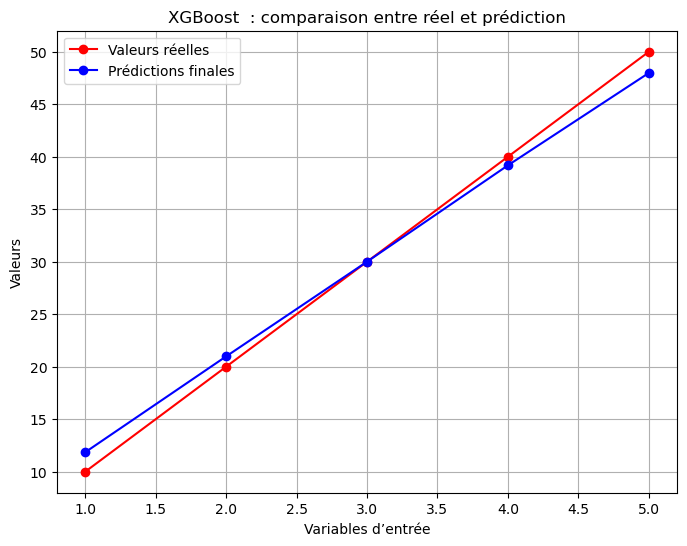

In [21]:
import numpy as np  # importation de la bibliothèque numpy pour les calculs numériques
import matplotlib.pyplot as plt  # importation de matplotlib pour les graphiques

# =========================================================
# 1. DONNÉES D’ENTRÉE
# =========================================================

variables_entree = np.array([1, 2, 3, 4, 5])  
# définition des variables d’entrée (features)

valeurs_reelles = np.array([10, 20, 30, 40, 50])  
# définition des valeurs cibles (target)

# =========================================================
# 2. PARAMÈTRES DU MODÈLE
# =========================================================

taux_apprentissage = 0.3  
# taux d’apprentissage (learning rate) : contrôle l’amplitude des corrections

nombre_arbres = 10  
# nombre d’arbres utilisés dans le boosting

# =========================================================
# 3. INITIALISATION DE LA PRÉDICTION
# =========================================================

prediction_actuelle = np.full(len(valeurs_reelles), np.mean(valeurs_reelles))  
# initialisation des prédictions avec la moyenne des valeurs réelles

print("PRÉDICTION INITIALE :", prediction_actuelle)  
# affichage de la prédiction initiale

# =========================================================
# 4. BOUCLE D’APPRENTISSAGE (BOOSTING)
# =========================================================

for index_arbre in range(nombre_arbres):  
# boucle sur tous les arbres

    print("\n==============================")
    print("ARBRE NUMÉRO", index_arbre + 1)
    print("==============================")

    # =====================================================
    # 4.1 CALCUL DES ERREURS
    # =====================================================

    erreurs = valeurs_reelles - prediction_actuelle  
    # calcul des erreurs entre valeurs réelles et prédictions

    print("ERREURS :", erreurs)  
    # affichage des erreurs

    # =====================================================
    # 4.2 RECHERCHE DU MEILLEUR SEUIL
    # =====================================================

    meilleur_gain = -1  
    # initialisation du meilleur gain

    meilleur_seuil = None  
    # initialisation du meilleur seuil de séparation

    for seuil in variables_entree:  
    # test de chaque valeur comme seuil possible

        erreurs_gauche = erreurs[variables_entree <= seuil]  
        # erreurs pour la partie gauche

        erreurs_droite = erreurs[variables_entree > seuil]  
        # erreurs pour la partie droite

        if len(erreurs_gauche) == 0 or len(erreurs_droite) == 0:  
        # éviter les splits invalides
            continue  

        gain = abs(np.mean(erreurs_gauche) - np.mean(erreurs_droite))  
        # calcul du gain entre les deux groupes

        if gain > meilleur_gain:  
        # mise à jour du meilleur split
            meilleur_gain = gain  
            meilleur_seuil = seuil  

    # =====================================================
    # 4.3 CALCUL DES VALEURS DES FEUILLES
    # =====================================================

    valeur_gauche = np.mean(erreurs[variables_entree <= meilleur_seuil])  
    # correction de la feuille gauche

    valeur_droite = np.mean(erreurs[variables_entree > meilleur_seuil])  
    # correction de la feuille droite

    print("MEILLEUR SEUIL :", meilleur_seuil)  
    # affichage du meilleur seuil

    print("VALEUR GAUCHE :", valeur_gauche)  
    # affichage correction gauche

    print("VALEUR DROITE :", valeur_droite)  
    # affichage correction droite

    # =====================================================
    # 4.4 MISE À JOUR DES PRÉDICTIONS
    # =====================================================

    for index in range(len(variables_entree)):  
    # boucle sur chaque observation

        if variables_entree[index] <= meilleur_seuil:  
        # si la valeur est dans la partie gauche
            prediction_actuelle[index] += taux_apprentissage * valeur_gauche  
            # mise à jour avec correction gauche

        else:  
        # sinon partie droite
            prediction_actuelle[index] += taux_apprentissage * valeur_droite  
            # mise à jour avec correction droite

    print("PRÉDICTION MISE À JOUR :", prediction_actuelle)  
    # affichage des nouvelles prédictions

# =========================================================
# 5. RÉSULTATS FINAUX
# =========================================================

print("\n==============================")
print("RÉSULTAT FINAL")
print("==============================")

for index in range(len(variables_entree)):  
# affichage des résultats finaux

    print("\nVARIABLE D’ENTRÉE :", variables_entree[index])  
    # affichage de X

    print("VALEUR RÉELLE :", valeurs_reelles[index])  
    # affichage de y réel

    print("PRÉDICTION FINALE :", prediction_actuelle[index])  
    # affichage de la prédiction finale

# =========================================================
# 6. VISUALISATION GRAPHIQUE
# =========================================================

plt.figure(figsize=(8,6))  
# création de la figure

plt.plot(variables_entree, valeurs_reelles, 'ro-', label="Valeurs réelles")  
# affichage des valeurs réelles

plt.plot(variables_entree, prediction_actuelle, 'bo-', label="Prédictions finales")  
# affichage des prédictions finales

plt.title("XGBoost  : comparaison entre réel et prédiction")  
# titre du graphique

plt.xlabel("Variables d’entrée")  
# axe X

plt.ylabel("Valeurs")  
# axe Y

plt.legend()  
# légende

plt.grid()  
# grille

plt.show()  
# affichage du graphique